# 🔬 Fine-Tuning para Detecção de Code Smells — CodeT5 Unificado

**Modelo:** CodeT5 (`Salesforce/codet5-small`)  
**Dataset:** `MergedSmells.csv` — todos os tipos de smell combinados  
**Tarefa:** Classificação Binária — *Code Smell* (1) vs *Código Normal* (0)  
**Divisão:** 80% treino / 20% teste (estratificada)

---
> Com datasets grandes (70k/30k), alguns métodos contêm a string `</s>` embutida no código-fonte.
> O tokenizador T5 converte isso para tokens EOS extras, e `T5ForSequenceClassification`
> exige **exatamente 1 EOS por exemplo** no batch.
> **Dois níveis de proteção foram adicionados:**
> 1. `preprocess_code` remove `</s>` antes da tokenização
> 2. `CodeSmellDataset` sanitiza EOS duplicados após a tokenização

---
### 🗺️ Experimentos
| Experimento | Modelo  | Dataset       |
|-------------|---------|---------------|
| EXP-3       | CodeT5  | Mixed Smells  |

> **Nota sobre multi-GPU:** CodeT5 é um encoder-decoder T5 **incompatível com `DataParallel`**  
> (requer mesmo nº de tokens `<eos>` em cada sub-batch). Todo o treinamento ocorre em **GPU única**.


## 1. Instalação de Dependências

In [3]:
%%capture
!pip install transformers==4.40.0 datasets scikit-learn pandas numpy matplotlib seaborn torch accelerate -q

## 2. Importações

In [4]:
import os, re, json, random, warnings
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, roc_curve,
)

# CodeT5 nao usa DataParallel — sempre 1 GPU (ou CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports OK')
print(f'🔥 PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
print(f'🖥️  Dispositivo: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Imports OK
🔥 PyTorch 2.10.0+cu128 | CUDA: True
🖥️  Dispositivo: cuda
   GPU: Tesla T4


## 3. Configurações Globais

In [ ]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

# ── Batch size ────────────────────────────────────────────────
BATCH_SIZE = 16

CONFIG = {
    'mixed_smells_path'  : '/kaggle/input/datasets/rafaelstc12/mergedsmellsdataset/MergedSmells.csv',
    'output_dir'        : '/kaggle/working/',
    'test_size'         : 0.20,
    'max_length'        : 512,
    'batch_size'        : BATCH_SIZE,
    'num_epochs'        : 3,
    'learning_rate'     : 2e-5,
    'weight_decay'      : 0.01,
    'warmup_ratio'      : 0.04,
    'grad_clip'         : 1.0,
    'log_steps'         : 100,
    'codet5_name'       : 'Salesforce/codet5-small',
    'num_labels'        : 2,
}

EXP_COLORS = {
    'CodeT5 × Mixed Smells' : '#E65100',
}

n_train_mixed = int(100000 * (1 - CONFIG['test_size']))
for ds, n in [('Mixed Smells (100k est.)', n_train_mixed)]:
    steps = (n // CONFIG['batch_size']) * CONFIG['num_epochs']
    print(f'  {ds}: ~{steps:,} steps totais')

print(f'\n Dispositivo   : {DEVICE}')
print(f' batch_size    : {CONFIG["batch_size"]}  (single GPU — sem DataParallel)')
print(f' learning_rate : {CONFIG["learning_rate"]:.2e}')
print(f' max_length    : {CONFIG["max_length"]}  |  epochs: {CONFIG["num_epochs"]}')
print(f' log_steps     : {CONFIG["log_steps"]}')

  Mixed Smells (100k est.): ~15,000 steps totais

 Dispositivo   : cuda
 batch_size    : 16  (single GPU — sem DataParallel)
 learning_rate : 2.00e-05
 max_length    : 512  |  epochs: 3
 log_steps     : 100


## 4. Carregamento dos Dados

In [6]:
def load_and_clean(path: str, smell_type: str) -> pd.DataFrame:
    for encoding in ('utf-8', 'latin-1', 'cp1252', 'utf-8-sig'):
        try:
            df = pd.read_csv(
                path, sep=';', engine='python', quotechar='"',
                on_bad_lines='skip', encoding=encoding,
            )
            print(f'  [{smell_type}] encoding={encoding} | shape={df.shape}')
            break
        except UnicodeDecodeError:
            continue
    else:
        raise RuntimeError(f'Nao foi possivel ler {path}')

    df.columns = df.columns.str.strip().str.lower()
    col_map = {}
    for col in df.columns:
        if col in ('method','method_body','methodbody','code','source','sourcecode','method_code'):
            col_map[col] = 'method'
        elif col in ('severity','label','class','smell','is_smell','target','output'):
            col_map[col] = 'severity'
    df.rename(columns=col_map, inplace=True)
    assert 'method' in df.columns, f'Coluna codigo nao encontrada: {list(df.columns)}'
    assert 'severity' in df.columns, f'Coluna rotulo nao encontrada: {list(df.columns)}'
    df.dropna(subset=['method','severity'], inplace=True)
    df['severity']   = df['severity'].astype(int)
    df['method']     = df['method'].astype(str).str.strip()
    df['smell_type'] = smell_type
    return df[df['method'].str.len() > 0].reset_index(drop=True)

df_mixed = load_and_clean(CONFIG['mixed_smells_path'], 'mixed_smells')

print('=' * 52)
for name, df in [('Mixed Smells', df_mixed)]:
    n0 = (df['severity']==0).sum(); n1 = (df['severity']==1).sum()
    print(f'  {name:<14}: {len(df):>6,} exemplos  |  Normal={n0:,}  Smell={n1:,}')
print('=' * 52)

  [mixed_smells] encoding=utf-8 | shape=(104778, 3)
  Mixed Smells  : 104,778 exemplos  |  Normal=99,445  Smell=5,333


## 5. Utilitários — Dataset, Treino e Avaliação

In [7]:
import re as _re

def preprocess_code(code: str) -> str:
    code = _re.sub(r'/\*.*?\*/', ' ', code, flags=_re.DOTALL)
    code = _re.sub(r'//[^\n]*', ' ', code)
    code = code.replace('</s>', ' ')  # remove EOS tokens embutidos no codigo
    code = _re.sub(r'\s+', ' ', code)
    return code.strip()


class CodeSmellDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_length, return_tensors='pt',
        )
        # Sanitiza EOS: T5ForSequenceClassification exige exatamente 1 </s> por exemplo.
        # Datasets grandes podem conter </s> embutido no codigo-fonte, gerando EOS extras.
        eos_id = tokenizer.eos_token_id
        pad_id = tokenizer.pad_token_id
        ids = self.encodings['input_ids']
        for i in range(ids.shape[0]):
            eos_pos = (ids[i] == eos_id).nonzero(as_tuple=True)[0]
            if len(eos_pos) > 1:
                ids[i][eos_pos[:-1]] = pad_id  # mantém apenas o último EOS
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


def split_dataset(df: pd.DataFrame):
    df = df.copy()
    df['method_clean'] = df['method'].apply(preprocess_code)
    X, y = df['method_clean'].values, df['severity'].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=CONFIG['test_size'], random_state=SEED, stratify=y)
    print(f'   Treino: {len(X_tr):,}  (Normal={sum(y_tr==0):,} | Smell={sum(y_tr==1):,})')
    print(f'   Teste : {len(X_te):,}  (Normal={sum(y_te==0):,} | Smell={sum(y_te==1):,})')
    return X_tr, X_te, y_tr, y_te


def compute_metrics(y_true, y_pred, y_prob=None):
    m = {
        'accuracy'        : accuracy_score(y_true, y_pred),
        'precision_smell' : precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_smell'    : recall_score(y_true, y_pred,    pos_label=1, zero_division=0),
        'f1_smell'        : f1_score(y_true, y_pred,        pos_label=1, zero_division=0),
        'f1_macro'        : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted'     : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'mcc'             : matthews_corrcoef(y_true, y_pred),
    }
    if y_prob is not None:
        try:    m['roc_auc'] = roc_auc_score(y_true, y_prob)
        except: m['roc_auc'] = float('nan')
    return m


def train_model(model, train_loader, val_loader, exp_label, y_train):
    """
    Treina CodeT5-small em GPU unica.
    DataParallel e intencionalmente desativado: o T5 encoder-decoder
    requer mesmo numero de tokens <eos> em cada sub-batch, tornando
    a divisao automatica do DataParallel incompativel com essa arquitetura.
    """
    model.to(DEVICE)
    print(f'  🖥️  Treinando em: {DEVICE}')

    counts  = np.bincount(y_train)
    weights = torch.tensor(len(y_train) / (2 * counts), dtype=torch.float).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    print(f'  ⚖️  Class weights: Normal={weights[0]:.3f} | Smell={weights[1]:.3f}')

    optimizer    = AdamW(model.parameters(), lr=CONFIG['learning_rate'],
                         weight_decay=CONFIG['weight_decay'])
    total_steps  = len(train_loader) * CONFIG['num_epochs']
    warmup_steps = int(total_steps * CONFIG['warmup_ratio'])
    scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {'train_loss':[], 'val_loss':[], 'val_f1':[], 'val_f1_smell':[]}
    best_f1, best_state = 0.0, None

    for epoch in range(CONFIG['num_epochs']):
        model.train()
        total_tr = 0
        for step, batch in enumerate(train_loader):
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
            loss    = loss_fn(logits, batch['labels'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            total_tr += loss.item()
            if (step + 1) % CONFIG['log_steps'] == 0:
                print(f'  [{exp_label}] Ep {epoch+1} | Step {step+1}/{len(train_loader)} '
                      f'| Loss {total_tr/(step+1):.4f}')
        avg_tr = total_tr / len(train_loader)

        model.eval()
        total_val = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch   = {k: v.to(DEVICE) for k, v in batch.items()}
                outputs = model(**batch)
                logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
                total_val += loss_fn(logits, batch['labels']).item()
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(batch['labels'].cpu().numpy())

        avg_val      = total_val / len(val_loader)
        val_f1_smell = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
        val_f1       = f1_score(all_labels, all_preds, zero_division=0)
        val_recall   = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)

        history['train_loss'].append(avg_tr)
        history['val_loss'].append(avg_val)
        history['val_f1'].append(val_f1)
        history['val_f1_smell'].append(val_f1_smell)

        star = ''
        if val_f1_smell > best_f1:
            best_f1    = val_f1_smell
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            star = '  ✨ melhor F1-Smell!'
        print(f'  [{exp_label}] Ep {epoch+1}/{CONFIG["num_epochs"]} '
              f'| TrLoss {avg_tr:.4f} | ValLoss {avg_val:.4f} '
              f'| F1-Smell {val_f1_smell:.4f} | Recall {val_recall:.4f}{star}')

    if best_state:
        model.load_state_dict(best_state)
    print(f'✅ [{exp_label}] Concluido — melhor F1-Smell: {best_f1:.4f}\n')
    return model, history


def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
            all_probs.extend(torch.softmax(logits, dim=1)[:,1].cpu().numpy())
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def plot_experiment(history, y_true, y_pred, y_prob, exp_label, color, save_path):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f'📊 Resultados — {exp_label}', fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'o-',  color=color, linewidth=2, label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   's--', color=color, alpha=0.5,   linewidth=2, label='Val Loss')
    ax1r = ax1.twinx()
    ax1r.plot(epochs, history['val_f1'],       '^:', color='green',  linewidth=2, label='Val F1 Global')
    ax1r.plot(epochs, history['val_f1_smell'], 's-', color='purple', linewidth=2, label='Val F1 Smell ★')
    ax1r.set_ylabel('F1', color='green'); ax1r.tick_params(axis='y', labelcolor='green')
    l1, b1 = ax1.get_legend_handles_labels(); l2, b2 = ax1r.get_legend_handles_labels()
    ax1.legend(l1+l2, b1+b2, fontsize=8, loc='upper right')
    ax1.set_title('Curva de Treino', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:,np.newaxis] * 100
    annot  = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', ax=ax2, cmap=plt.cm.Oranges,
                xticklabels=['Normal','Smell'], yticklabels=['Normal','Smell'],
                linewidths=0.5, cbar=False, annot_kws={'size':11,'weight':'bold'})
    ax2.set_title('Matriz de Confusao', fontweight='bold')
    ax2.set_xlabel('Predito'); ax2.set_ylabel('Real')

    ax3 = fig.add_subplot(gs[0, 2])
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)
        ax3.plot(fpr, tpr, color=color, linewidth=2.5, label=f'AUC = {auc_val:.3f}')
    except Exception: pass
    ax3.plot([0,1],[0,1],'k--',linewidth=1)
    ax3.set_title('Curva ROC', fontweight='bold')
    ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR'); ax3.legend(); ax3.grid(True,alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 0])
    ax4.hist(y_prob[y_true==0], bins=30, alpha=0.6, color='#4CAF50', label='Normal (real)')
    ax4.hist(y_prob[y_true==1], bins=30, alpha=0.6, color='#F44336', label='Smell (real)')
    ax4.axvline(0.5, color='black', linestyle='--', linewidth=1.5)
    ax4.set_title('Distribuicao das Probabilidades', fontweight='bold')
    ax4.set_xlabel('P(Smell)'); ax4.legend(fontsize=8)

    ax5 = fig.add_subplot(gs[1, 1])
    metrics  = compute_metrics(y_true, y_pred, y_prob)
    met_keys = ['accuracy','precision_smell','recall_smell','f1_smell','f1_macro','mcc']
    met_lbls = ['Accuracy','Precision Smell','Recall Smell','F1 Smell ★','F1 Macro','MCC']
    vals = [metrics[k] for k in met_keys]
    bars = ax5.barh(met_lbls, vals, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax5.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
    ax5.set_xlim(0, 1.15); ax5.set_title('Metricas de Classificacao', fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

    ax6 = fig.add_subplot(gs[1, 2]); ax6.axis('off')
    report = classification_report(y_true, y_pred, target_names=['Normal','Smell'], output_dict=True)
    rows = []
    for cls in ['Normal','Smell','macro avg','weighted avg']:
        r = report.get(cls, {})
        rows.append([cls, f"{r.get('precision',0):.3f}", f"{r.get('recall',0):.3f}",
                     f"{r.get('f1-score',0):.3f}", f"{int(r.get('support',0))}"])
    tbl = ax6.table(cellText=rows, colLabels=['Classe','Prec','Rec','F1','Support'],
                    cellLoc='center', loc='center', bbox=[0.0,0.1,1.0,0.85])
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    for (row,col), cell in tbl.get_celld().items():
        if row==0: cell.set_facecolor('#37474F'); cell.set_text_props(color='white',fontweight='bold')
        elif row%2==0: cell.set_facecolor('#ECEFF1')
    ax6.set_title('Classification Report', fontweight='bold')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Painel salvo em {save_path}')
    return metrics


print('✅ Todos os utilitarios definidos!')
print('   Single GPU / CPU — DataParallel desativado (incompativel com CodeT5)')

✅ Todos os utilitarios definidos!
   Single GPU / CPU — DataParallel desativado (incompativel com CodeT5)


## 6. Tokenizador CodeT5

In [8]:
tok_ct = AutoTokenizer.from_pretrained(CONFIG['codet5_name'])
print(f'✅ Tokenizador: {CONFIG["codet5_name"]}')
print(f'   Vocab size: {tok_ct.vocab_size:,}')

# num_workers: 2 e seguro em Kaggle/Colab
_NW = 2

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

✅ Tokenizador: Salesforce/codet5-small
   Vocab size: 32,100


## 7. EXP-3 — CodeT5 × Mixed Smells


In [9]:
print('='*55)
print('  🟠 EXP-3 — CodeT5 × Mixed Smells')
print('='*55)

X_tr, X_te, y_tr, y_te = split_dataset(df_mixed)

train_ds_mixed = CodeSmellDataset(X_tr, y_tr, tok_ct, CONFIG['max_length'])
test_ds_mixed  = CodeSmellDataset(X_te, y_te, tok_ct, CONFIG['max_length'])
train_dl_mixed = DataLoader(train_ds_mixed, batch_size=CONFIG['batch_size'], shuffle=True,
                            num_workers=_NW, pin_memory=True, persistent_workers=True)
test_dl_mixed  = DataLoader(test_ds_mixed,  batch_size=CONFIG['batch_size'], shuffle=False,
                            num_workers=_NW, pin_memory=True, persistent_workers=True)

model_ct_mixed = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['codet5_name'], num_labels=CONFIG['num_labels'])

model_ct_mixed, hist_ct_mixed = train_model(model_ct_mixed, train_dl_mixed, test_dl_mixed,
                                             'CodeT5×MixedSmells', y_tr)


  🟠 EXP-3 — CodeT5 × Mixed Smells
   Treino: 83,822  (Normal=79,556 | Smell=4,266)
   Teste : 20,956  (Normal=19,889 | Smell=1,067)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at Salesforce/codet5-small and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  🖥️  Treinando em: cuda
  ⚖️  Class weights: Normal=0.527 | Smell=9.824
  [CodeT5×MixedSmells] Ep 1 | Step 100/5239 | Loss 0.8033
  [CodeT5×MixedSmells] Ep 1 | Step 200/5239 | Loss 0.8590
  [CodeT5×MixedSmells] Ep 1 | Step 300/5239 | Loss 1.0102
  [CodeT5×MixedSmells] Ep 1 | Step 400/5239 | Loss 1.1114
  [CodeT5×MixedSmells] Ep 1 | Step 500/5239 | Loss 1.0724
  [CodeT5×MixedSmells] Ep 1 | Step 600/5239 | Loss 1.0584
  [CodeT5×MixedSmells] Ep 1 | Step 700/5239 | Loss 1.0524
  [CodeT5×MixedSmells] Ep 1 | Step 800/5239 | Loss 1.0215
  [CodeT5×MixedSmells] Ep 1 | Step 900/5239 | Loss 0.9966
  [CodeT5×MixedSmells] Ep 1 | Step 1000/5239 | Loss 0.9517
  [CodeT5×MixedSmells] Ep 1 | Step 1100/5239 | Loss 0.9391
  [CodeT5×MixedSmells] Ep 1 | Step 1200/5239 | Loss 0.9161
  [CodeT5×MixedSmells] Ep 1 | Step 1300/5239 | Loss 0.8971
  [CodeT5×MixedSmells] Ep 1 | Step 1400/5239 | Loss 0.9015
  [CodeT5×MixedSmells] Ep 1 | Step 1500/5239 | Loss 0.8843
  [CodeT5×MixedSmells] Ep 1 | Step 1600/5239 | Loss

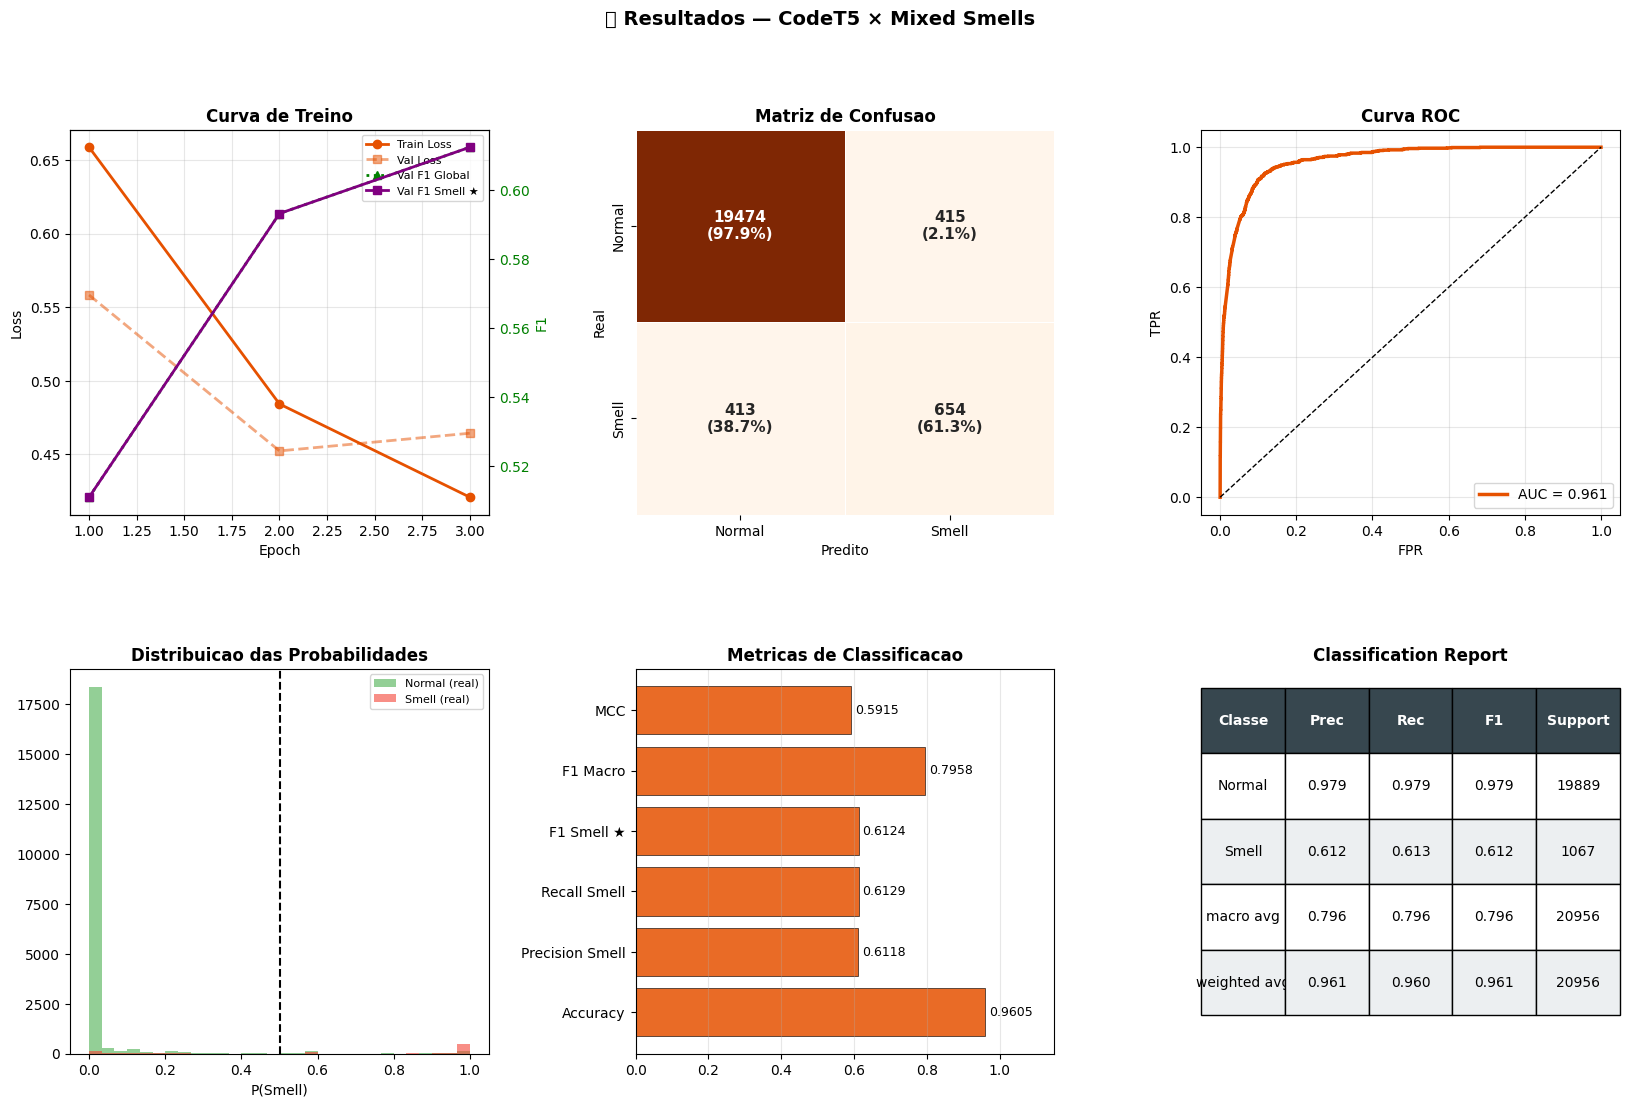

💾 Painel salvo em /kaggle/working/exp3_codet5_mixedsmells.png

📋 Classification Report completo — CodeT5 × Mixed Smells
              precision    recall  f1-score   support

  Normal (0)       0.98      0.98      0.98     19889
   Smell (1)       0.61      0.61      0.61      1067

    accuracy                           0.96     20956
   macro avg       0.80      0.80      0.80     20956
weighted avg       0.96      0.96      0.96     20956



In [10]:
lbl_ct_mixed, pred_ct_mixed, prob_ct_mixed = evaluate_model(model_ct_mixed, test_dl_mixed)

metrics_ct_mixed = plot_experiment(
    history   = hist_ct_mixed,
    y_true    = lbl_ct_mixed,
    y_pred    = pred_ct_mixed,
    y_prob    = prob_ct_mixed,
    exp_label = 'CodeT5 × Mixed Smells',
    color     = EXP_COLORS['CodeT5 × Mixed Smells'],
    save_path = f"{CONFIG['output_dir']}exp3_codet5_mixedsmells.png",
)

print('\n📋 Classification Report completo — CodeT5 × Mixed Smells')
print(classification_report(lbl_ct_mixed, pred_ct_mixed, target_names=['Normal (0)','Smell (1)']))


## 8. Resultados Finais


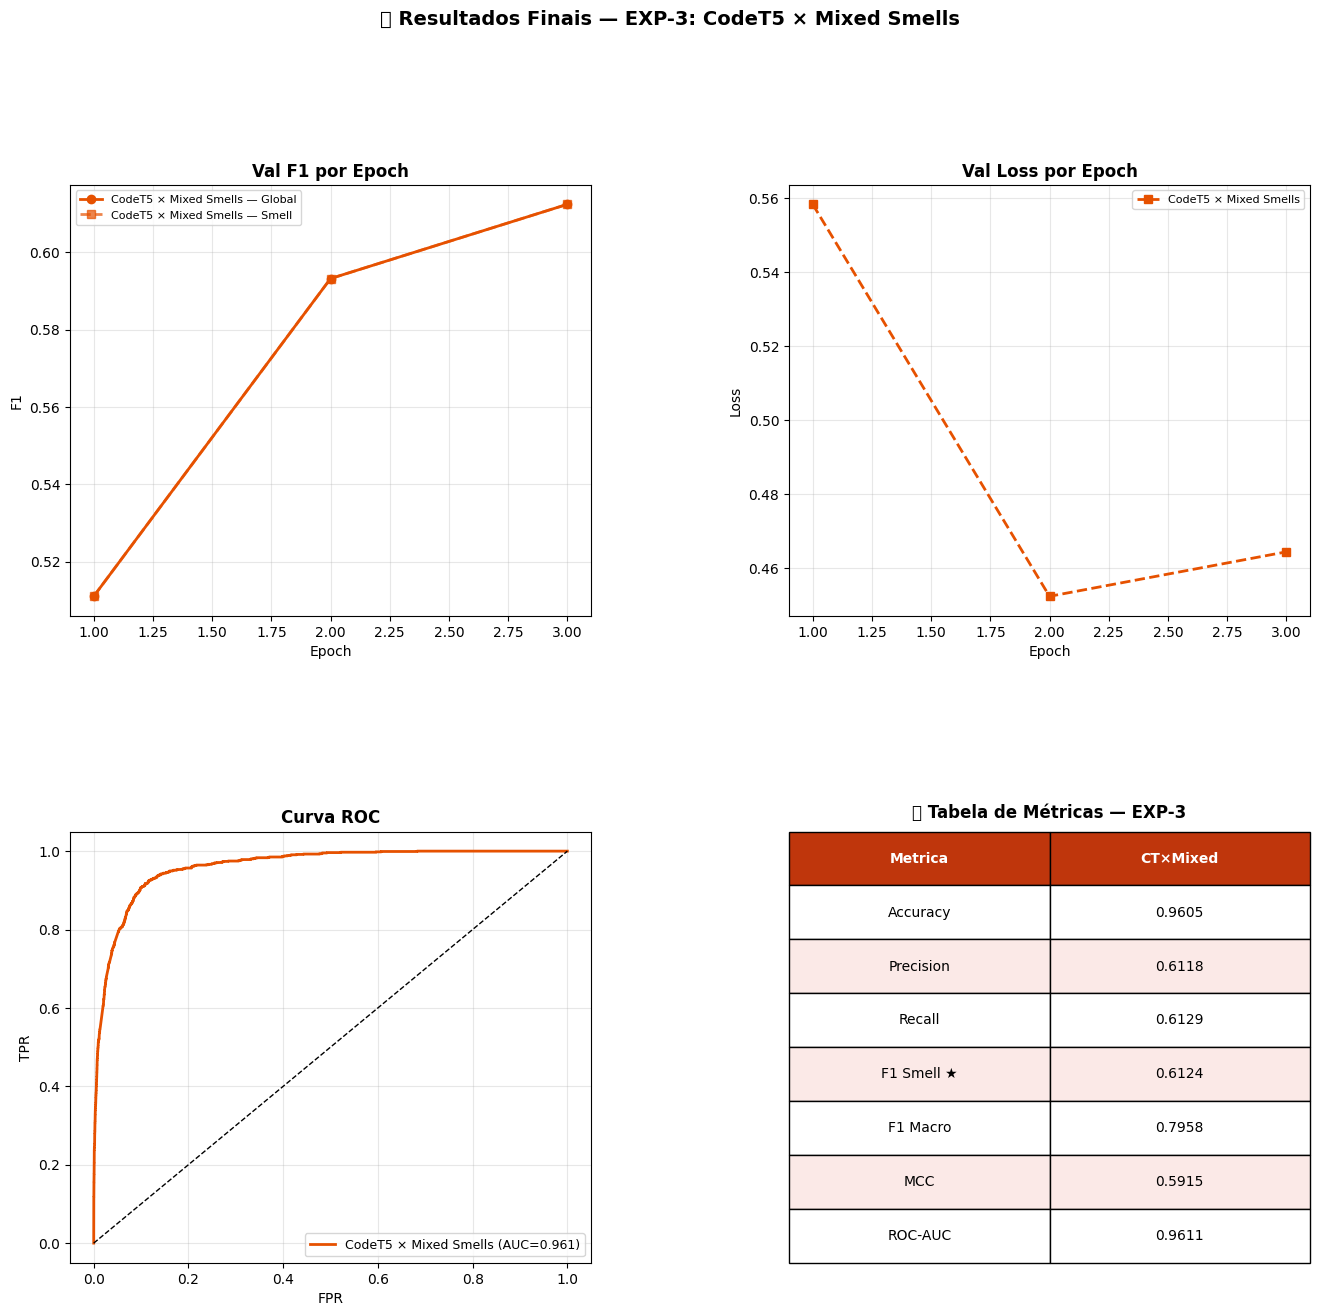

✅ Resultados finais salvos!


In [11]:
EXPERIMENTS = {
    'CodeT5 × Mixed Smells' : (metrics_ct_mixed, hist_ct_mixed, lbl_ct_mixed, pred_ct_mixed, prob_ct_mixed),
}
exp_order = list(EXPERIMENTS.keys())

fig = plt.figure(figsize=(16, 14))
fig.suptitle('🏆 Resultados Finais — EXP-3: CodeT5 × Mixed Smells',
             fontsize=14, fontweight='bold', y=1.005)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.38)

ax_f1 = fig.add_subplot(gs[0, 0])
for exp, (_, hist, *_) in EXPERIMENTS.items():
    ep = range(1, len(hist['val_f1']) + 1)
    ax_f1.plot(ep, hist['val_f1'],       'o-',  color=EXP_COLORS[exp], linewidth=2, label=f'{exp} — Global')
    ax_f1.plot(ep, hist['val_f1_smell'], 's--', color=EXP_COLORS[exp], linewidth=2, alpha=0.7, label=f'{exp} — Smell')
ax_f1.set_title('Val F1 por Epoch', fontweight='bold')
ax_f1.set_xlabel('Epoch'); ax_f1.set_ylabel('F1')
ax_f1.legend(fontsize=8); ax_f1.grid(True, alpha=0.3)

ax_loss = fig.add_subplot(gs[0, 1])
for exp, (_, hist, *_) in EXPERIMENTS.items():
    ep = range(1, len(hist['val_loss']) + 1)
    ax_loss.plot(ep, hist['val_loss'], 's--', color=EXP_COLORS[exp], linewidth=2, label=exp)
ax_loss.set_title('Val Loss por Epoch', fontweight='bold')
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)

ax_roc = fig.add_subplot(gs[1, 0])
for exp, (_, _, y_true, _, y_prob) in EXPERIMENTS.items():
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)
        ax_roc.plot(fpr, tpr, color=EXP_COLORS[exp], linewidth=2,
                    label=f'{exp} (AUC={auc_val:.3f})')
    except Exception: pass
ax_roc.plot([0,1],[0,1],'k--',linewidth=1)
ax_roc.set_title('Curva ROC', fontweight='bold')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=9); ax_roc.grid(True, alpha=0.3)

ax_tbl = fig.add_subplot(gs[1, 1]); ax_tbl.axis('off')
met_keys = ['accuracy','precision_smell','recall_smell','f1_smell','f1_macro','mcc','roc_auc']
met_lbls = ['Accuracy','Precision','Recall','F1 Smell ★','F1 Macro','MCC','ROC-AUC']
table_rows = []
for lbl, key in zip(met_lbls, met_keys):
    vals = [EXPERIMENTS[e][0].get(key, float('nan')) for e in exp_order]
    row  = [lbl] + [f'{v:.4f}' if not np.isnan(v) else 'N/A' for v in vals]
    table_rows.append(row)
tbl = ax_tbl.table(cellText=table_rows, colLabels=['Metrica','CT×Mixed'],
                   cellLoc='center', loc='center', bbox=[0.0,0.0,1.0,1.0])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (row,col), cell in tbl.get_celld().items():
    if row==0: cell.set_facecolor('#BF360C'); cell.set_text_props(color='white',fontweight='bold')
    elif row%2==0: cell.set_facecolor('#FBE9E7')
ax_tbl.set_title('📋 Tabela de Métricas — EXP-3', fontweight='bold', pad=10)

plt.savefig(f"{CONFIG['output_dir']}resultados_finais_codet5.png", dpi=150, bbox_inches='tight')
plt.show()
print('✅ Resultados finais salvos!')


In [12]:
print('\n' + '='*52)
print(f'  {"RESUMO FINAL — EXP-3: CodeT5 × Mixed Smells":^48}')
print('='*52)
met_keys = ['accuracy','precision_smell','recall_smell','f1_smell','f1_macro','mcc','roc_auc']
met_lbls = ['Accuracy','Precision','Recall','F1 Smell ★','F1 Macro','MCC','ROC-AUC']
print(f'  {"Metrica":<20} {"CT×Mixed":>10}')
print('-'*52)
for lbl, key in zip(met_lbls, met_keys):
    v = metrics_ct_mixed.get(key, float('nan'))
    val_str = f'{v:>9.4f}' if v == v else f'{'N/A':>9}'
    print(f'  {lbl:<20} {val_str}')
print('='*52)
print('  CT=CodeT5  Mixed=Mixed Smells (todos os tipos)')



    RESUMO FINAL — EXP-3: CodeT5 × Mixed Smells   
  Metrica                CT×Mixed
----------------------------------------------------
  Accuracy                0.9605
  Precision               0.6118
  Recall                  0.6129
  F1 Smell ★              0.6124
  F1 Macro                0.7958
  MCC                     0.5915
  ROC-AUC                 0.9611
  CT=CodeT5  Mixed=Mixed Smells (todos os tipos)


## 9. Salvamento dos Modelos e Resultados


In [13]:
save_map = {
    'codet5_mixedsmells' : (model_ct_mixed, tok_ct),
}

for folder_name, (model, tokenizer) in save_map.items():
    save_path = f"{CONFIG['output_dir']}{folder_name}"
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f'  💾 Salvo: {save_path}')

all_results = {}
for exp, (metrics, _, *_) in EXPERIMENTS.items():
    all_results[exp] = {k: round(float(v), 6) for k, v in metrics.items()}
all_results['config'] = {k: str(v) for k, v in CONFIG.items()}

json_path = f"{CONFIG['output_dir']}results_codet5_mixed.json"
with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'\n  📄 Metricas JSON: {json_path}')
print('\n✅ Tudo salvo com sucesso!')


  💾 Salvo: /kaggle/working/codet5_mixedsmells

  📄 Metricas JSON: /kaggle/working/results_codet5_mixed.json

✅ Tudo salvo com sucesso!
